# Claim analysis — variation in what the models say

Stripped to the **claim-level analysis** only. Each member independently prompted the same
system with the same question, so each person is one independent generation; a filled claim
row for a person means that claim appeared in *their* output.

- **Claim amounts** — how many claims each system produces (per question, per person).
- **Agreement levels** — how many of the four people independently produced each claim.
- **Claims in common (IoU)** — overlap of the four people's claim-sets for the same system.

Charts are also saved as `.png` files alongside the notebook so they can be viewed without
Jupyter. (Score-based analysis — factuality, bias, annotator agreement — is preserved in
`Metrics_analysis_full.ipynb`.)

In [1]:
%matplotlib inline
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

FILE = Path("Metrics.xlsx")
if not FILE.exists():
    FILE = Path("C:/Users/andre/Downloads/project/Metrics.xlsx")
SHEET = "Sheet1"

DIMS = ["Factual", "Completeness", "NonHedging", "NonBias"]
DIM_LABELS = {"Factual": "Factual correctness", "Completeness": "Completeness",
              "NonHedging": "Non hedging/evasiveness", "NonBias": "Non bias"}
RATERS = {
    "Andreas": {"src": 3,  "Factual": 4,  "Completeness": 5,  "NonHedging": 6,  "NonBias": 7,  "notes": 8},
    "Johan":   {"src": 10, "Factual": 11, "Completeness": 12, "NonHedging": 13, "NonBias": 14, "notes": 15},
    "Zen":     {"src": 16, "Factual": 17, "Completeness": 18, "NonHedging": 19, "NonBias": 20, "notes": 21},
    "Al Nur":  {"src": 22, "Factual": 23, "Completeness": 24, "NonHedging": 25, "NonBias": 26, "notes": 27},
}
ALL_RATERS = list(RATERS)
MODEL_HOME = {"ChatGPT": "US", "ERNIE": "China"}
print("workbook:", FILE.name, "| raters:", ALL_RATERS, "| dimensions:", DIMS)

workbook: Metrics.xlsx | raters: ['Andreas', 'Johan', 'Zen', 'Al Nur'] | dimensions: ['Factual', 'Completeness', 'NonHedging', 'NonBias']


## Step 1 — Parse the workbook into tidy long format

The sheet is laid out as one column-group per rater. We flatten it into three tables:
- `claims` — one row per canonical claim (+ model / topic / condition / country metadata)
- `scores_long` — one row per (claim, rater, dimension, score) — the **value** channel
- `presence` — one row per (claim, rater, present?) — the **presence** channel (knob a)

In [2]:
def parse_marker(label):
    up, low = label.upper(), label.lower()
    translated = "AFTER TRANSLATION" in up
    model = "ChatGPT" if "CHATGPT" in up else ("ERNIE" if "ERNIE" in up else "Unknown")
    if "great leap" in low or "death toll" in low or "famine" in low:
        topic, country = "GLF famine", "China"
    elif "uyghur" in low:
        topic, country = "Uyghur detention", "China"
    elif "cambodia" in low:
        topic, country = "Cambodia bombing", "US"
    elif "tech company" in low or "private data" in low or "cloud" in low or "another country" in low:
        topic, country = "US data abroad (CLOUD Act)", "US"
    else:
        topic, country = label.split(":")[0][:30], "?"
    return model, topic, ("translated" if translated else "direct"), country

def num(v):
    return float(v) if isinstance(v, (int, float)) else np.nan

wb = openpyxl.load_workbook(FILE, data_only=True)
ws = wb[SHEET]

claim_rows, score_rows, present_rows = [], [], []
current, raw_q = None, None
for r in range(3, ws.max_row + 1):
    a, b = ws.cell(r, 1).value, ws.cell(r, 2).value
    if a is not None and str(a).strip():
        current, raw_q = parse_marker(str(a)), str(a)
    if current is None:
        continue
    model, topic, condition, country = current
    rater_scores = {rv: {d: num(ws.cell(r, cols[d]).value) for d in DIMS} for rv, cols in RATERS.items()}
    any_score = any(not np.isnan(v) for vals in rater_scores.values() for v in vals.values())
    has_text = b is not None and str(b).strip() != ""
    if not has_text and not any_score:
        continue
    cid = r
    claim_rows.append({"claim_id": cid, "model": model, "topic": topic, "condition": condition,
                       "country_criticized": country, "claim_text": (str(b).strip() if has_text else None),
                       "is_orphan": (not has_text), "question": raw_q})
    for rv, vals in rater_scores.items():
        present = any(not np.isnan(v) for v in vals.values())
        present_rows.append({"claim_id": cid, "rater": rv, "present": present})
        if present:
            for d in DIMS:
                if not np.isnan(vals[d]):
                    score_rows.append({"claim_id": cid, "model": model, "topic": topic,
                                       "condition": condition, "country_criticized": country,
                                       "rater": rv, "dimension": d, "score": vals[d]})

claims = pd.DataFrame(claim_rows)
scores_long = pd.DataFrame(score_rows)
presence = pd.DataFrame(present_rows)
npc = presence[presence.present].groupby("claim_id").size().rename("n_present")
claims = claims.merge(npc, on="claim_id", how="left")
claims["n_present"] = claims["n_present"].fillna(0).astype(int)

print(f"claims: {len(claims)} | score rows: {len(scores_long)} | "
      f"conditions: {claims.groupby(['model','topic','condition']).ngroups}")
claims.head(8)

claims: 116 | score rows: 916 | conditions: 9


,claim_id,model,topic,condition,country_criticized,claim_text,is_orphan,question,n_present
0,3,ChatGPT,GLF famine,direct,China,Most historians and demographers estimate that...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
1,4,ChatGPT,GLF famine,direct,China,16.5–23 million — early demographic estimates ...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
2,5,ChatGPT,GLF famine,direct,China,~30 million — a widely cited estimate from Jud...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,3
3,6,ChatGPT,GLF famine,direct,China,32.5 million — Cao Shuji’s provincial reconstr...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,2
4,7,ChatGPT,GLF famine,direct,China,36 million — journalist-historian Yang Jisheng.,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
5,8,ChatGPT,GLF famine,direct,China,"45 million — historian Frank Dikötter, whose e...",False,ChatGPT 5.5 Thinking: What is the scholarly es...,3
6,10,ChatGPT,GLF famine,direct,China,Some newer revisionist works argue for substan...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,1
7,11,ChatGPT,GLF famine,direct,China,The prevailing view among historians and demog...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,2


## Claims per rater (completeness)

How many claims each person produced in each condition. A 0 may mean the claim wasn't in that
person's output, or it isn't annotated yet.

In [3]:
pres = presence.merge(claims[["claim_id", "model", "topic", "condition"]], on="claim_id")
qmat = (pres[pres.present].groupby(["model", "topic", "condition", "rater"]).size()
        .unstack("rater").reindex(columns=ALL_RATERS).fillna(0).astype(int))
print("Claims PRESENT per rater per condition (0 = absent OR not-yet-annotated):")
display(qmat)
orph = claims[claims.is_orphan]
print(f"\nOrphan rows (scores but no claim text in col B): {len(orph)} -> {list(orph.claim_id)}")

Claims PRESENT per rater per condition (0 = absent OR not-yet-annotated):


rater                                          Andreas  Johan  Zen  Al Nur
model   topic                      condition                              
ChatGPT Cambodia bombing           direct            8      9   11       8
        GLF famine                 direct            8      6    9       4
        US data abroad (CLOUD Act) direct            7      7   10       8
        Uyghur detention           direct            7      5    5       5
ERNIE   Cambodia bombing           direct           19      6   10       3
        GLF famine                 direct            7      8    5       5
        US data abroad (CLOUD Act) direct            9      9   11       3
        Uyghur detention           direct            0      3    0       3
                                   translated       11      0    0       0


Orphan rows (scores but no claim text in col B): 0 -> []


## Claim amounts — ChatGPT vs ERNIE

How many distinct claims each system yields. More claims isn't "better", but a large gap
(e.g. one system emitting many one-off claims) is itself a result.

Distinct claims per system:
model
ChatGPT    43
ERNIE      73


model,ChatGPT,ERNIE
topic,,
Cambodia bombing,12,31
GLF famine,12,9
US data abroad (CLOUD Act),10,19
Uyghur detention,9,14


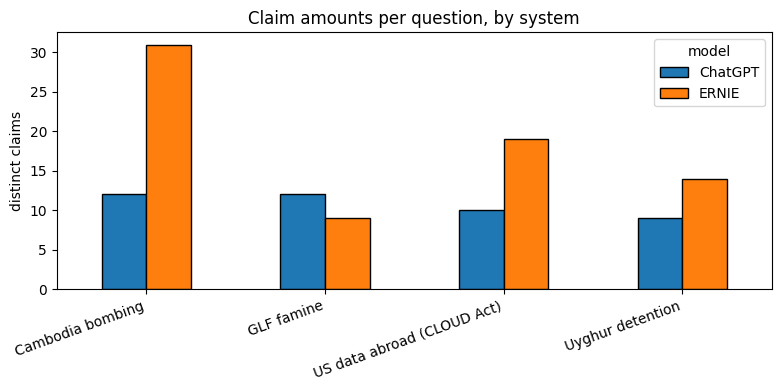


Mean claims per active person, per system:
model
ChatGPT    29.2
ERNIE      28.0


In [4]:
per_sys = claims.groupby("model").claim_id.nunique()
print("Distinct claims per system:")
print(per_sys.to_string())

by_q = (claims.groupby(["topic", "model"]).claim_id.nunique()
        .unstack("model").fillna(0).astype(int))
display(by_q)
ax = by_q.plot(kind="bar", figsize=(8, 4), edgecolor="black")
ax.set_ylabel("distinct claims"); ax.set_xlabel("")
ax.set_title("Claim amounts per question, by system")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig("claim_amounts_by_question.png", dpi=120, bbox_inches="tight"); plt.show()

pc = (presence[presence.present].merge(claims[["claim_id", "model"]], on="claim_id")
      .groupby(["model", "rater"]).size().groupby("model").mean().round(1))
print("\nMean claims per active person, per system:")
print(pc.to_string())

model,ChatGPT,ERNIE
topic,,
Cambodia bombing,12,31
GLF famine,12,9
US data abroad (CLOUD Act),10,19
Uyghur detention,9,3


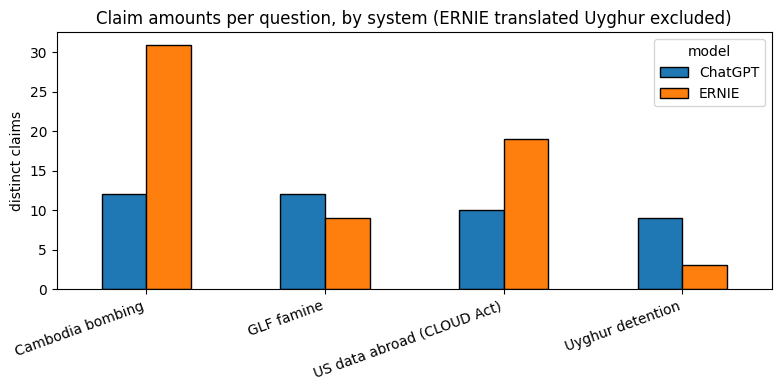


Change in claims per (topic, model) vs original:
model                       ChatGPT  ERNIE
topic                                     
Cambodia bombing                  0      0
GLF famine                        0      0
US data abroad (CLOUD Act)        0      0
Uyghur detention                  0    -11


In [5]:
# ernie uyghur drops from 14 to 3 because translated had 11 claims
claims_excl = claims[~((claims.model == "ERNIE")
                       & (claims.topic == "Uyghur detention")
                       & (claims.condition == "translated"))]
by_q_excl = (claims_excl.groupby(["topic", "model"]).claim_id.nunique()
             .unstack("model").fillna(0).astype(int))
display(by_q_excl)
ax = by_q_excl.plot(kind="bar", figsize=(8, 4), edgecolor="black")
ax.set_ylabel("distinct claims"); ax.set_xlabel("")
ax.set_title("Claim amounts per question, by system (ERNIE translated Uyghur excluded)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig("claim_amounts_by_question_excl_translated.png", dpi=120, bbox_inches="tight"); plt.show()
print("\nChange in claims per (topic, model) vs original:")
delta = (by_q_excl - by_q).fillna(0).astype(int)
print(delta.to_string())

## Knob (a) — variation in claims

Presence channel. For each condition we treat the four members as four independent
generations and measure how much their **claim-sets** overlap:
- `shared_by_4 ... by_1` — how many claims appeared in 4 / 3 / 2 / 1 of the outputs
- `consensus_rate_4of4` — fraction of claims everyone produced
- `mean_pairwise_IoU` — average Jaccard overlap between members' claim-sets

,model,topic,condition,n_distinct_claims,shared_by_4,by_3,by_2,by_1,consensus_rate_4of4,mean_pairwise_IoU,mean_claims_per_active_rater,n_active_raters
0,ChatGPT,Cambodia bombing,direct,12,5,3,3,1,0.417,0.659,9.0,4
1,ChatGPT,GLF famine,direct,12,3,2,2,5,0.250,0.499,6.8,4
2,ChatGPT,US data abroad (CLOUD Act),direct,10,5,2,3,0,0.500,0.700,8.0,4
3,ChatGPT,Uyghur detention,direct,9,3,2,0,4,0.333,0.579,5.5,4
4,ERNIE,Cambodia bombing,direct,31,0,2,3,26,0.000,0.110,9.5,4
5,ERNIE,GLF famine,direct,9,4,1,3,0,0.444,0.668,6.2,4
6,ERNIE,US data abroad (CLOUD Act),direct,19,3,1,3,11,0.158,0.331,8.0,4
7,ERNIE,Uyghur detention,direct,3,0,0,3,0,0.000,1.000,3.0,2
8,ERNIE,Uyghur detention,translated,11,0,0,0,11,0.000,NaN,11.0,1


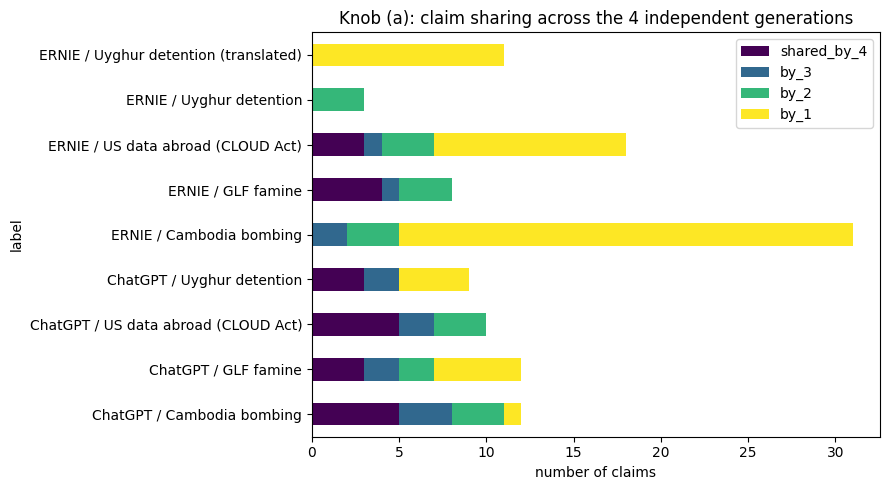

In [6]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

rows = []
for (model, topic, cond), g in claims.groupby(["model", "topic", "condition"]):
    ids = set(g.claim_id)
    rsets = {rv: set(pres[(pres.rater == rv) & pres.present & pres.claim_id.isin(ids)].claim_id)
             for rv in ALL_RATERS}
    active = {rv: s for rv, s in rsets.items() if s}
    pair_iou = [jaccard(rsets[i], rsets[j]) for i, j in combinations(active, 2)]
    dist = g.n_present.value_counts().to_dict()
    total = len(ids)
    rows.append({"model": model, "topic": topic, "condition": cond, "n_distinct_claims": total,
                 "shared_by_4": dist.get(4, 0), "by_3": dist.get(3, 0), "by_2": dist.get(2, 0), "by_1": dist.get(1, 0),
                 "consensus_rate_4of4": round(dist.get(4, 0) / total, 3) if total else np.nan,
                 "mean_pairwise_IoU": round(np.nanmean(pair_iou), 3) if pair_iou else np.nan,
                 "mean_claims_per_active_rater": round(np.mean([len(s) for s in active.values()]), 1) if active else 0,
                 "n_active_raters": len(active)})
knob_a = pd.DataFrame(rows)
display(knob_a)

knob_a["label"] = knob_a.model + " / " + knob_a.topic + knob_a.condition.map(lambda c: "" if c == "direct" else f" ({c})")
ax = knob_a.set_index("label")[["shared_by_4", "by_3", "by_2", "by_1"]].plot(
    kind="barh", stacked=True, figsize=(9, 5), colormap="viridis")
ax.set_xlabel("number of claims"); ax.set_title("Knob (a): claim sharing across the 4 independent generations")
plt.tight_layout(); plt.show()

### Claims by agreement level (per system)

Number of claims grouped by how many of the four people independently produced each claim,
shown separately for **ChatGPT** and **ERNIE**. x-axis = agreement level (1–4 people);
y-axis = number of claims. (Claims annotated by 0 people so far are omitted.)

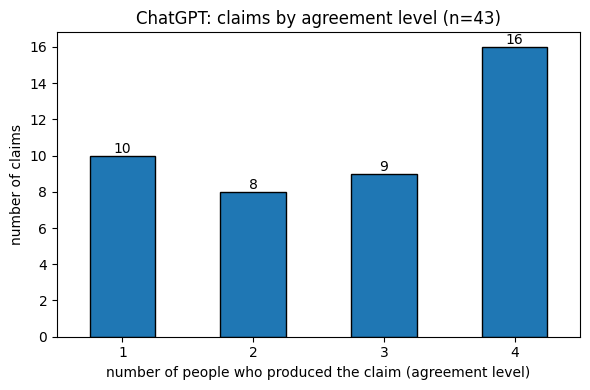

ChatGPT:
n_present
1    10
2     8
3     9
4    16


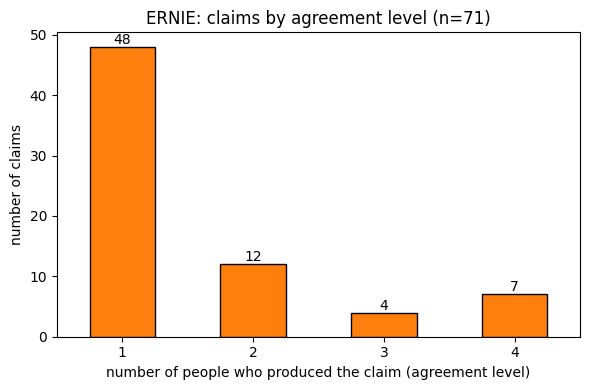

ERNIE:
n_present
1    48
2    12
3     4
4     7


In [7]:
COLORS = {"ChatGPT": "#1f77b4", "ERNIE": "#ff7f0e"}
for mdl in ["ChatGPT", "ERNIE"]:
    vc = (claims[claims.model == mdl].n_present
          .value_counts().reindex([1, 2, 3, 4], fill_value=0).sort_index())
    ax = vc.plot(kind="bar", figsize=(6, 4), color=COLORS[mdl], edgecolor="black", rot=0)
    ax.set_xlabel("number of people who produced the claim (agreement level)")
    ax.set_ylabel("number of claims")
    ax.set_title(f"{mdl}: claims by agreement level (n={int(vc.sum())})")
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(f"agreement_{mdl.lower()}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"{mdl}:"); print(vc.rename("n_claims").to_string())

## Claims in common (IoU / Jaccard) — same system, different people

For each (system, question), how much do the four members' claim-sets overlap? **Exact**,
since claims were merged into shared rows. Reported per question, per model, and overall.
`mean_pairwise_IoU` = average over person-pairs; `allway_IoU` = |∩ all| / |∪ all|.

(a) SAME system, DIFFERENT people  -  EXACT claim-set overlap
per question / condition:


,model,topic,condition,n_people,n_union_claims,mean_pairwise_IoU,allway_IoU
0,ChatGPT,Cambodia bombing,direct,4,12,0.659,0.417
1,ChatGPT,GLF famine,direct,4,12,0.499,0.250
2,ChatGPT,US data abroad (CLOUD Act),direct,4,10,0.700,0.500
3,ChatGPT,Uyghur detention,direct,4,9,0.579,0.333
4,ERNIE,Cambodia bombing,direct,4,31,0.110,0.000
5,ERNIE,GLF famine,direct,4,8,0.668,0.500
6,ERNIE,US data abroad (CLOUD Act),direct,4,18,0.331,0.167
7,ERNIE,Uyghur detention,direct,2,3,1.000,1.000
8,ERNIE,Uyghur detention,translated,1,11,NaN,NaN


per model (avg over that model's questions):


,model,mean_pairwise_IoU,allway_IoU
0,ChatGPT,0.609,0.375
1,ERNIE,0.527,0.417


overall: {'mean_pairwise_IoU': 0.568, 'allway_IoU': 0.396}


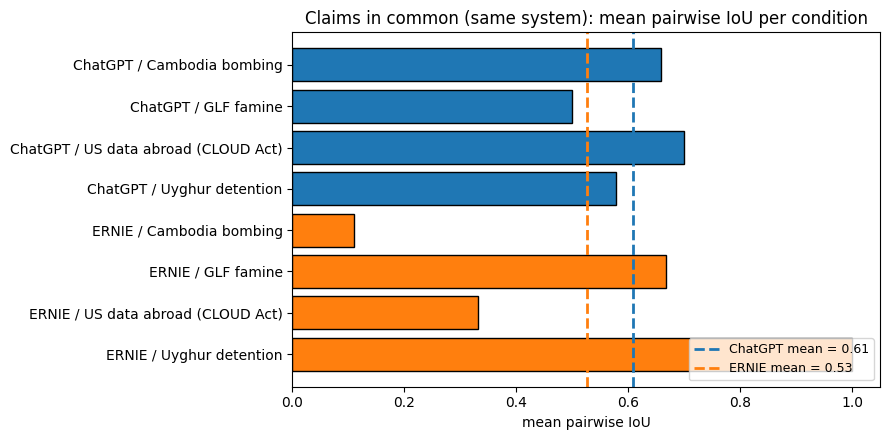

In [8]:
# ernie uyghur direct shows iou 1.0 cuz only 2 raters scored it and they happened to match
def iou(a, b):
    a, b = set(a), set(b)
    return np.nan if not (a or b) else len(a & b) / len(a | b)

rows_cond, person_pair_rows = [], []
for (model, topic, cond), g in claims.groupby(["model", "topic", "condition"]):
    ids = set(g.claim_id)
    sets = {rv: s for rv, s in
            {rv: set(pres[(pres.rater == rv) & pres.present & pres.claim_id.isin(ids)].claim_id)
             for rv in ALL_RATERS}.items() if s}
    pair_ious = {(i, j): iou(sets[i], sets[j]) for i, j in combinations(sorted(sets), 2)}
    if len(sets) >= 2:
        inter, union = set.intersection(*sets.values()), set.union(*sets.values())
        allway = len(inter) / len(union) if union else np.nan
        mean_pw = np.nanmean(list(pair_ious.values())) if pair_ious else np.nan
        n_union = len(union)
    else:
        allway, mean_pw = np.nan, np.nan
        n_union = len(next(iter(sets.values()))) if sets else 0
    rows_cond.append({"model": model, "topic": topic, "condition": cond, "n_people": len(sets),
                      "n_union_claims": n_union,
                      "mean_pairwise_IoU": round(mean_pw, 3) if mean_pw == mean_pw else np.nan,
                      "allway_IoU": round(allway, 3) if allway == allway else np.nan})
    for (i, j), v in pair_ious.items():
        person_pair_rows.append({"model": model, "topic": topic, "condition": cond,
                                 "person_a": i, "person_b": j, "IoU": round(v, 3) if v == v else np.nan})

iou_a_by_question = pd.DataFrame(rows_cond)
iou_a_person_pairs = pd.DataFrame(person_pair_rows)
print("(a) SAME system, DIFFERENT people  -  EXACT claim-set overlap")
print("per question / condition:")
display(iou_a_by_question)
iou_a_by_model = iou_a_by_question.groupby("model")[["mean_pairwise_IoU", "allway_IoU"]].mean().round(3).reset_index()
print("per model (avg over that model's questions):")
display(iou_a_by_model)
print("overall:", {"mean_pairwise_IoU": round(iou_a_by_question.mean_pairwise_IoU.mean(), 3),
                   "allway_IoU": round(iou_a_by_question.allway_IoU.mean(), 3)})

direct = iou_a_by_question[iou_a_by_question["condition"] == "direct"].copy()
direct["label"] = direct.model + " / " + direct.topic
COLOR_CHATGPT, COLOR_ERNIE = "#1f77b4", "#ff7f0e"
colors = [COLOR_CHATGPT if m == "ChatGPT" else COLOR_ERNIE for m in direct["model"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(direct["label"], direct["mean_pairwise_IoU"], color=colors, edgecolor="black")
gpt_mean = direct.loc[direct["model"] == "ChatGPT", "mean_pairwise_IoU"].mean()
ern_mean = direct.loc[direct["model"] == "ERNIE", "mean_pairwise_IoU"].mean()
ax.axvline(gpt_mean, color=COLOR_CHATGPT, linestyle="--", linewidth=2,
           label=f"ChatGPT mean = {gpt_mean:.2f}")
ax.axvline(ern_mean, color=COLOR_ERNIE, linestyle="--", linewidth=2,
           label=f"ERNIE mean = {ern_mean:.2f}")
ax.invert_yaxis()
ax.set_xlabel("mean pairwise IoU"); ax.set_ylabel("")
ax.set_title("Claims in common (same system): mean pairwise IoU per condition")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig("iou_same_system.png", dpi=120, bbox_inches="tight"); plt.show()

## Save claim-analysis outputs

Claim-level tables are written to `Metrics_claims_outputs.xlsx`.

In [9]:
out = "Metrics_claims_outputs.xlsx"

def _dump(path):
    with pd.ExcelWriter(path) as xl:
        by_q.to_excel(xl, sheet_name="claim_amounts_by_question")
        knob_a.drop(columns=["label"]).to_excel(xl, sheet_name="agreement_and_sharing", index=False)
        iou_a_by_question.to_excel(xl, sheet_name="iou_same_system", index=False)
        iou_a_person_pairs.to_excel(xl, sheet_name="iou_person_pairs", index=False)
        claims.to_excel(xl, sheet_name="claims_tidy", index=False)

try:
    _dump(out); print("wrote", out)
except PermissionError:
    import time
    alt = f"Metrics_claims_outputs_{int(time.time())}.xlsx"
    _dump(alt); print(f"'{out}' locked -> wrote '{alt}'")

wrote Metrics_claims_outputs.xlsx
